In [ ]:
import cell2location
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs
from pathlib import Path
from scipy import sparse # Dealing with adata data dyptes numbers

import torch
torch.set_float32_matmul_precision("high")  # or "medium"
# to deal with this warning
# You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. 
# To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` 
# which will trade-off precision for performance. For more details, read 
# https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision

In [ ]:
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel

## SC: GPU

In [5]:
# SC for GPU
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))


Torch version: 2.7.1
CUDA available: False
CUDA version (torch): None
GPU count: 0


In [7]:
# import torch, scvi
# print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

# Data

## Locations

In [ ]:
# Project folder
proj_folder   = Path("/Users/janzules/Roselab/Spatial/CAR_T/")

# Files for training and mapping
input_folder  = proj_folder / "Results/cell2location/C2L_inputs/"

figures_folder = proj_folder / "figures/cell2location/training"


ref_loc       = input_folder / "ref_adata_c2l_model.h5ad"
# spatial_loc   = input_folder / "spatial_adata_c2l_model.h5ad"

# Output location - Not sure what these are for
# ref_run_name   = proj_folder / "reference_signatures"
# run_name       = proj_folder / "cell2location_map"

# After training
adata_out     = input_folder / "sc_with_signatures.h5ad"

In [22]:
# Load data
adata_ref = sc.read_h5ad(ref_loc)

## Processing Data

In [27]:
# ensure that the data is in the correct format for cell2location
# needs to be: type(adata_ref.X), adata_ref.X.dtype
adata_ref.X = adata_ref.X.tocsr()
adata_ref.X.data = adata_ref.X.data.astype(np.float32)

type(adata_ref.X), adata_ref.X.dtype

(scipy.sparse._csr.csr_matrix, dtype('float32'))

# Training

With Alice's annotations we should use these labels:

* cell_type_lvl1
* cell_type_lvl2
* cell_type_lvl3

In [ ]:
levels = ["cell_type_lvl1", "cell_type_lvl2", "cell_type_lvl3"]

level_short = {
    "cell_type_lvl1": "lvl1",
    "cell_type_lvl2": "lvl2",
    "cell_type_lvl3": "lvl3",
}

In [36]:
import numpy as np
from scipy import sparse

X = adata_ref.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = np.asarray(X).ravel()

print("dtype:", vals.dtype)
print("min:", vals.min() if vals.size else None)
print("max:", vals.max() if vals.size else None)
print("first 20 unique values:", np.unique(vals[:10000])[:20])
print("fraction non-integer:", np.mean(vals != np.round(vals)) if vals.size else None)

dtype: float32
min: 0.14961758
max: 8.125639
first 20 unique values: [0.3302474  0.366193   0.53988767 0.5780868  0.6336451  0.7765398
 0.84445125 0.88856107 0.94205564 1.0184625  1.0840269  1.1465901
 1.1666347  1.2083255  1.2956586  1.3188679  1.3515105  1.4099218
 1.418398   1.4952986 ]
fraction non-integer: 1.0


/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


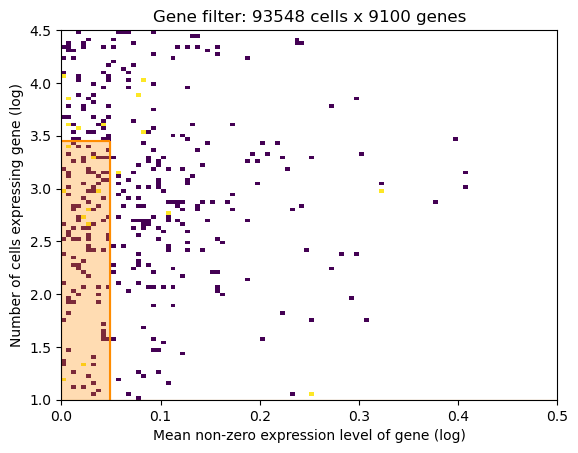

In [32]:
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)